# Example
## Generating Perturbed Input Ensembles

An example showing how to generate different sets of ensembles using the submodule
`perturbed_input` and the function `generate_ensemble`.

A detailed overview of the module can be found in the `perturbed_input` [README](ml_fw\perturbed_input\README.md).

Ensembels are generated using ARIMA residual resampling. The ensembles can be used in
modelling workflows to generate ensemble members for characterize probabilistic model outputs, 
sensitivity analysis, uncertainty quantification, boosting prediction accuracy, 
reducing overfitting, and improving model stability. 

### Method Overview

The perturbation workflow has four main steps:

1. Fit an ARIMA model to an input signal (or a separate reference signal).
2. Extract the residuals from the fitted model.
3. Analyze the residuals using statistical diagnostics.
4. Resample the residuals and add them to the input signal.

The residual is defined as:

$$
    e_t = y_t - \hat{y}_t
$$

where:

- $y_t$ is time series to be fitted
- $\hat{y}_t$ is the fitted ARIMA signal
- $e_t$ is the residual error

Each perturbed ensemble member is generated as:

$$
    y_i = y + e_i
$$

where:

- `y` is the  input signal
- `e_i` is a newly sampled residual sequence

Note that $y$ and $y_t$ the input signal and fitted time series can be different so that
residuals can be drawn over extended periods or from specific periods of interest (e.g. 
geomagnetic storms).

We'll use omni

### Example 1: Perturbed input from an input series

We'll use OMNI data throughout to generate various ensemble sets.

2003 is a partciluarly interesting time period, we'll use June through August to run
through a few examples.


In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from ml_fw.perturbed_input import generate_perturbations
from ml_fw.perturbed_input import plot_ensemble
from ml_fw.data import loaders

seed = 17 # for selecting residuals

In [3]:
dat = loaders.omni(start='2003-01-01',end='2003-12-31').reset_index(names='DateTime')
dat.tail(4)

,DateTime,bartels_rotation,imf_sc_id,plasma_sc_id,n_imf_obs,n_plasma_obs,b_mag_avg,b_vec_mag,b_lat_gse,b_lon_gse,...,prot_flux_10mev,prot_flux_30mev,prot_flux_60mev,flag,ap,f107,pc_n,al,au,m_sonic_mach
8733,2003-12-30 21:00:00,2326.0,71.0,71.0,16.0,16.0,7.6,3.8,-9.1,308.1,...,NaN,NaN,NaN,NaN,9.0,104.2,1.1,-45.0,98.0,4.9
8734,2003-12-30 22:00:00,2326.0,71.0,71.0,15.0,15.0,5.6,3.3,-15.1,330.8,...,NaN,NaN,NaN,NaN,9.0,104.2,0.4,-25.0,95.0,6.7
8735,2003-12-30 23:00:00,2326.0,71.0,71.0,16.0,16.0,3.3,3.2,-30.8,87.6,...,0.17,0.16,0.16,-1.0,9.0,104.2,0.6,-81.0,76.0,8.0
8736,2003-12-31 00:00:00,2326.0,71.0,71.0,15.0,15.0,1.8,1.7,-24.8,87.3,...,NaN,NaN,NaN,NaN,15.0,102.1,0.4,-88.0,93.0,8.6


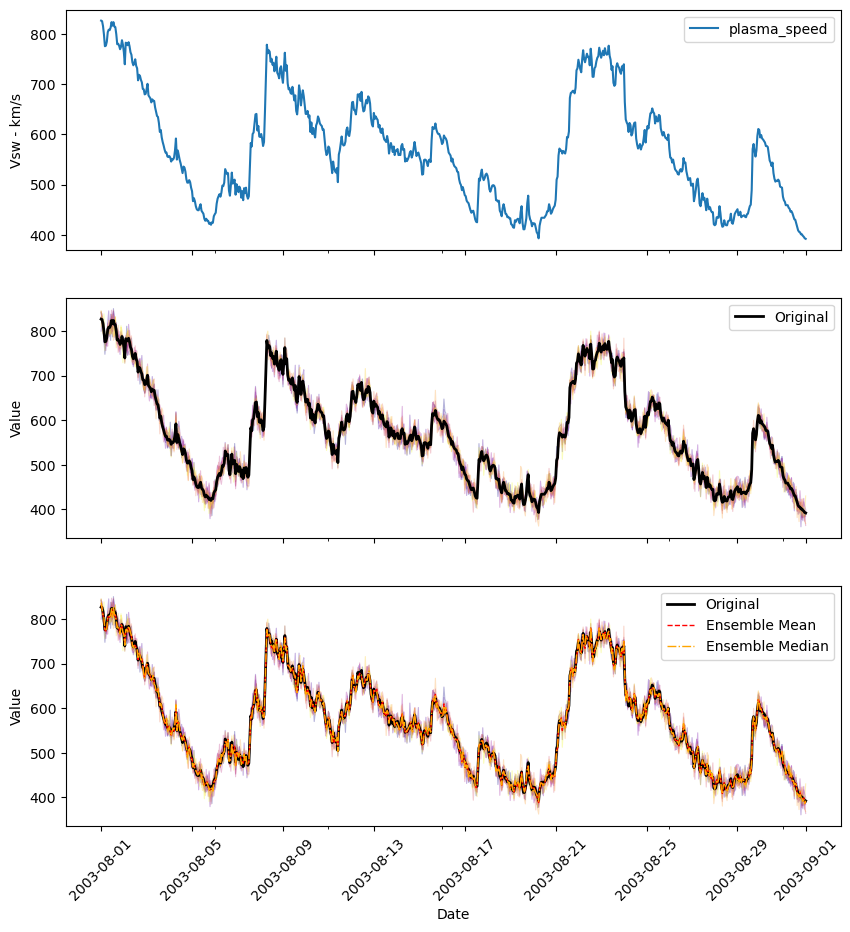

In [16]:
# grab a chunk of data which will be used to characterize residuals
# by fitting an ARIMA model and then generate perturbed inputs
# residuals are are sample using a gaussian
sdate = '2003-08-01'
edate = '2003-09-01'

y_dat = dat[(dat['DateTime'] >= sdate) & (dat['DateTime'] <= edate)][['DateTime','plasma_speed']]
ens_dat = generate_perturbations(y_dat['plasma_speed'].to_numpy(), 
                                 n_ensemble=10, seed=seed, method='gaussian')

fig, ax = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
# Plot the original data
_ = y_dat.plot(x='DateTime', y='plasma_speed', ylabel='Vsw - km/s', ax=ax[0], x_compat=True)

# Plot the original data and ensemble members
_ = plot_ensemble(y_dat['DateTime'].to_numpy(), y_dat['plasma_speed'].to_numpy(), 
                  ens_dat, ax=ax[1])

# same as above with the mean and median of the ensemble members
_ = plot_ensemble(y_dat['DateTime'].to_numpy(), y_dat['plasma_speed'].to_numpy(), 
                  ens_dat, ax=ax[2], plot_mean=True, plot_median=True, xlabel='Date')

Create a similar plot but return the fitted ARIMA model and plot it over the orignal
data

C:\Users\murph\AppData\Local\Temp\ipykernel_24040\4159817113.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax[0].plot(y_dat['DateTime'].to_numpy(), fitted_dat, color='orange', linestyle='--', label='ARIMA Fit')


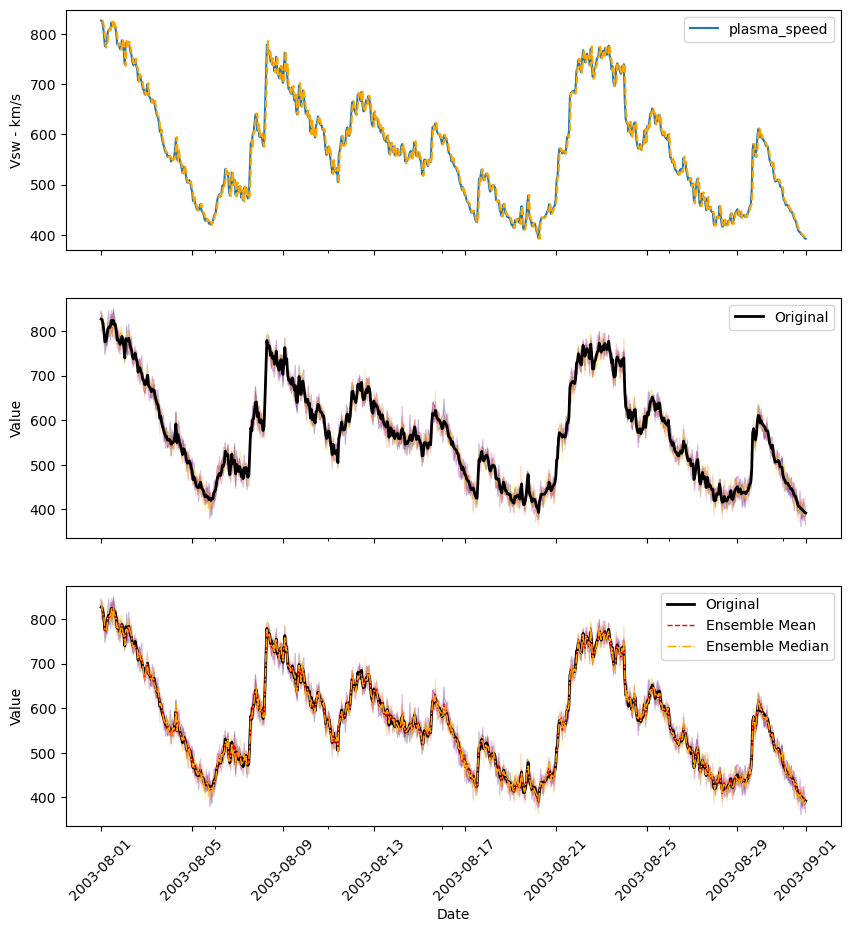

In [17]:
# Generate ensemble again and return the fitted values from the ARIMA model
ens_dat, fitted_dat = generate_perturbations(y_dat['plasma_speed'].to_numpy(), 
                                 n_ensemble=10, seed=seed, method='gaussian',
                                 return_fitted=True)

fig, ax = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# plot the original data and the ARIMA git
_ = y_dat.plot(x='DateTime', y='plasma_speed', ylabel='Vsw - km/s', ax=ax[0], x_compat=True)
ax[0].plot(y_dat['DateTime'].to_numpy(), fitted_dat, color='orange', linestyle='--', label='ARIMA Fit')

# Plot the ensemble
_ = plot_ensemble(y_dat['DateTime'].to_numpy(), y_dat['plasma_speed'].to_numpy(), 
                  ens_dat, ax=ax[1])
_ = plot_ensemble(y_dat['DateTime'].to_numpy(), y_dat['plasma_speed'].to_numpy(), 
                  ens_dat, ax=ax[2], plot_mean=True, plot_median=True, xlabel='Date')

### Example 2 Residuals defined from one period and added to another

Define residuals using period 1 and block sample them to add them to period 2. 

Block sampling is ideal as it selects a block of residuals with a specified number 
of samples as opposed to randomly sampling from the residuals. This preservers correlations
in the residuals.

Defining residuals from a seperate time period also allows us to use an extended period
to define residuals to get a better characterization of the residuals.


In [22]:
# define the period where we will fit the ARIMA model to characterize residuals
fit_dat = dat[(dat['DateTime'] >= '2003-06-01') & (dat['DateTime'] <= '2003-07-31')][['DateTime','plasma_speed']]


# create ensembles using the block method and fit the ARIMA model to the fit_dat
ens_dat, fitted_dat = generate_perturbations(y_dat['plasma_speed'].to_numpy(), n_ensemble=10, seed=17, 
                                 method='block', fit_ts=fit_dat['plasma_speed'].to_numpy(), 
                                 return_fitted=True, verbose=True, block_length=100)

Series 0:
  Noise source     : fit_ts
  ARIMA order      : (0, 1, 0)  seasonal: (0, 0, 0, 0)
  Sampling method  : block
  Block length     : 100


C:\Users\murph\AppData\Local\Temp\ipykernel_24040\2517775388.py:4: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax[0].plot(fit_dat['DateTime'].to_numpy(), fitted_dat, color='orange', linestyle='--', label='ARIMA Fit')


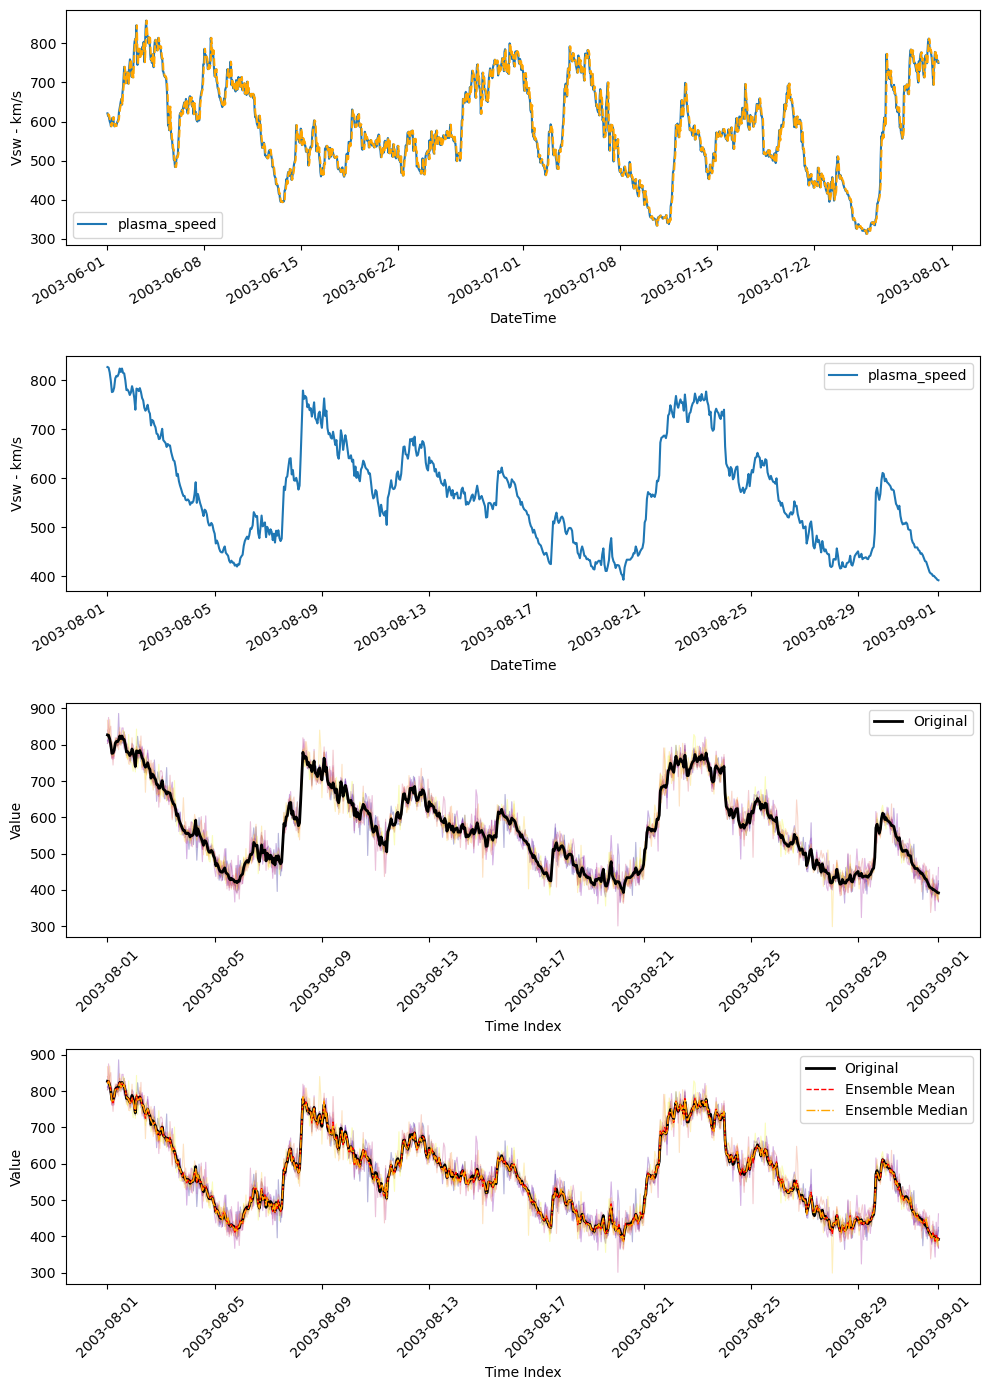

In [21]:
fig, ax = plt.subplots(4, 1, figsize=(10, 14), sharex=False)

_ = fit_dat.plot(x='DateTime', y='plasma_speed', ylabel='Vsw - km/s', ax=ax[0], x_compat=True)
ax[0].plot(fit_dat['DateTime'].to_numpy(), fitted_dat, color='orange', linestyle='--', label='ARIMA Fit')
# First plot establishes the datetime x-axis for all shared axes
_ = y_dat.plot(x='DateTime', y='plasma_speed', ylabel='Vsw - km/s', ax=ax[1], x_compat=True)
# Now plot_ensemble will use the same datetime x-axis
_ = plot_ensemble(y_dat['DateTime'].to_numpy(), y_dat['plasma_speed'].to_numpy(), 
                  ens_dat, ax=ax[2])
_ = plot_ensemble(y_dat['DateTime'].to_numpy(), y_dat['plasma_speed'].to_numpy(), 
                  ens_dat, ax=ax[3], plot_mean=True, plot_median=True)

fig.tight_layout()

### Example 3 Perturbed input ensembles for multiple time series

We'll build off of the previous example and build a ensemble member for multiple 
solar wind variables using `genertate_perturbations` vectorization.

When using vectorization each time-series passed is fitted with its own ARIMA model.
We don't use vector ARIMA as its a difficult process to automate. Residuals are then 
derived and sample to create ensembles. If no sampling method is set an auto method is
selected individually for each time series based on the residual diagnostics. Here we'll
 still use block sampling.



In [ ]:
# lets get the fit data and the 

cols = ['bz_gsm', 'plasma_speed', 'flow_pressure','DateTime']
col_t = ['Bz - nT', 'Vsw - km/s', 'Pdyn - nPa','DateTime']

fit_dat = dat[(dat['DateTime'] >= '2003-06-01') & (dat['DateTime'] <= '2003-07-31')][cols]

y_dat = dat[(dat['DateTime'] >= sdate) & (dat['DateTime'] <= edate)][cols]
ens_dat = generate_perturbations(y_dat['plasma_speed'].to_numpy(), 
                                 n_ensemble=10, seed=seed, method='gaussian')

In [34]:
ens_dat, fitted_dat = generate_perturbations(y_dat[cols[1:]].to_numpy(), n_ensemble=10, seed=17, 
                                 method='block', fit_ts=fit_dat[cols[1:]].to_numpy(), 
                                 return_fitted=True, block_length=100)

**Plot the data we've fit to and it's fit**

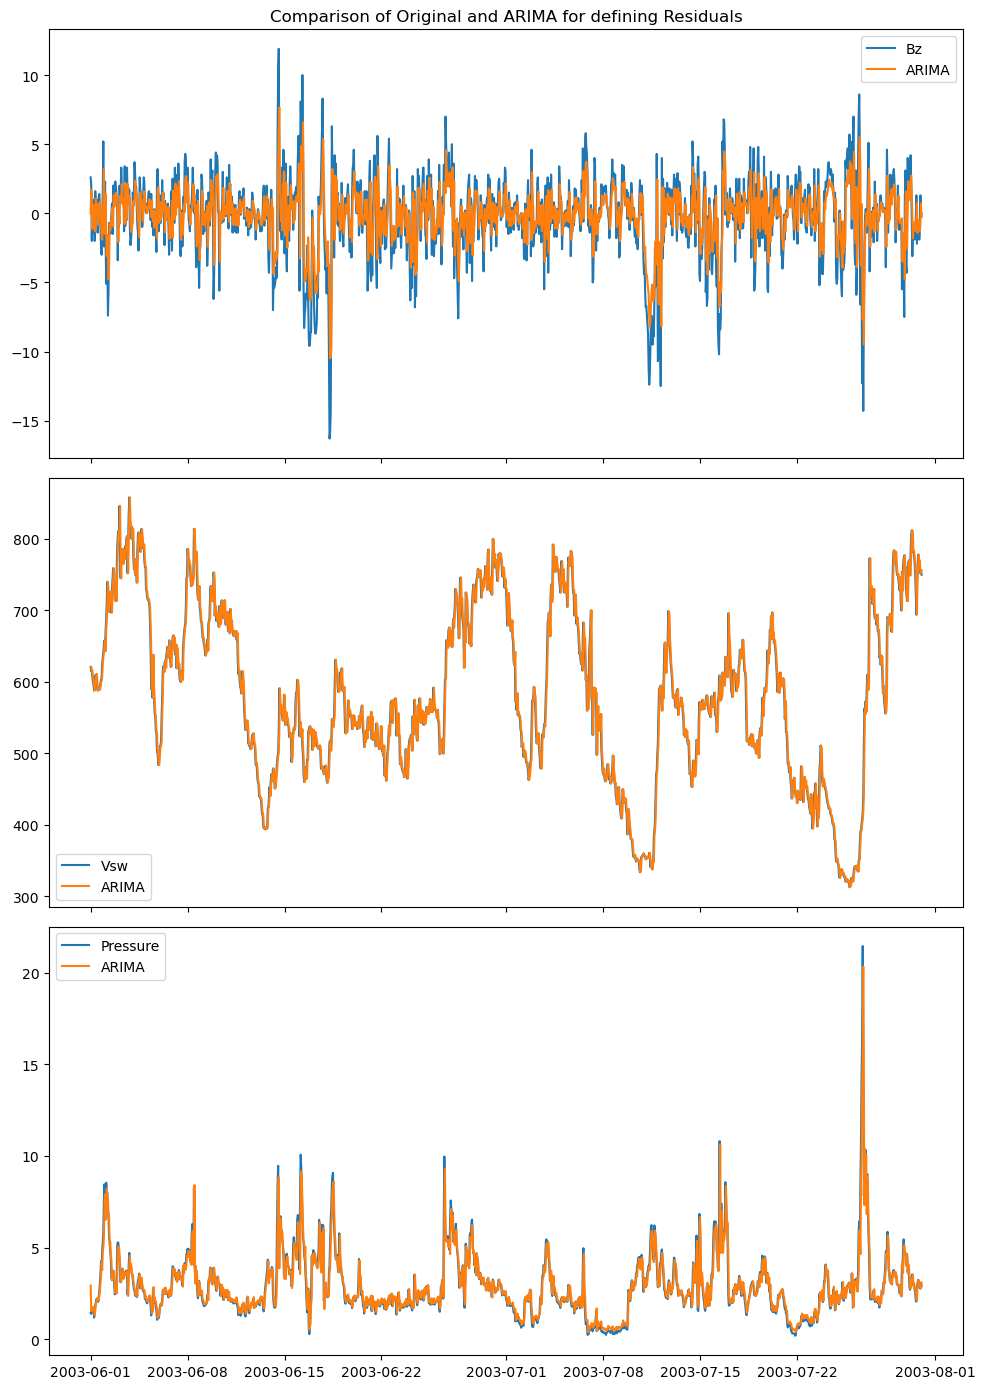

In [46]:
fig, ax = plt.subplots(3, 1, figsize=(10, 14), sharex=True)

ax[0].plot(fit_dat['DateTime'].to_numpy(), fit_dat[cols[1]].to_numpy(), label='Bz')
ax[0].plot(fit_dat['DateTime'].to_numpy(), fitted_dat[:,0], label='ARIMA')
ax[0].legend()
ax[0].set_title('Comparison of Original and ARIMA for defining Residuals')

ax[1].plot(fit_dat['DateTime'].to_numpy(), fit_dat[cols[2]].to_numpy(), label='Vsw')
ax[1].plot(fit_dat['DateTime'].to_numpy(), fitted_dat[:,1], label='ARIMA')
ax[1].legend()

ax[2].plot(fit_dat['DateTime'].to_numpy(), fit_dat[cols[3]].to_numpy(), label='Pressure')
ax[2].plot(fit_dat['DateTime'].to_numpy(), fitted_dat[:,2], label='ARIMA')
ax[2].legend()

fig.tight_layout()

**Now lets plot the ensembles over the period of interest.**

In [48]:
ens_dat.shape

(10, 745, 3)

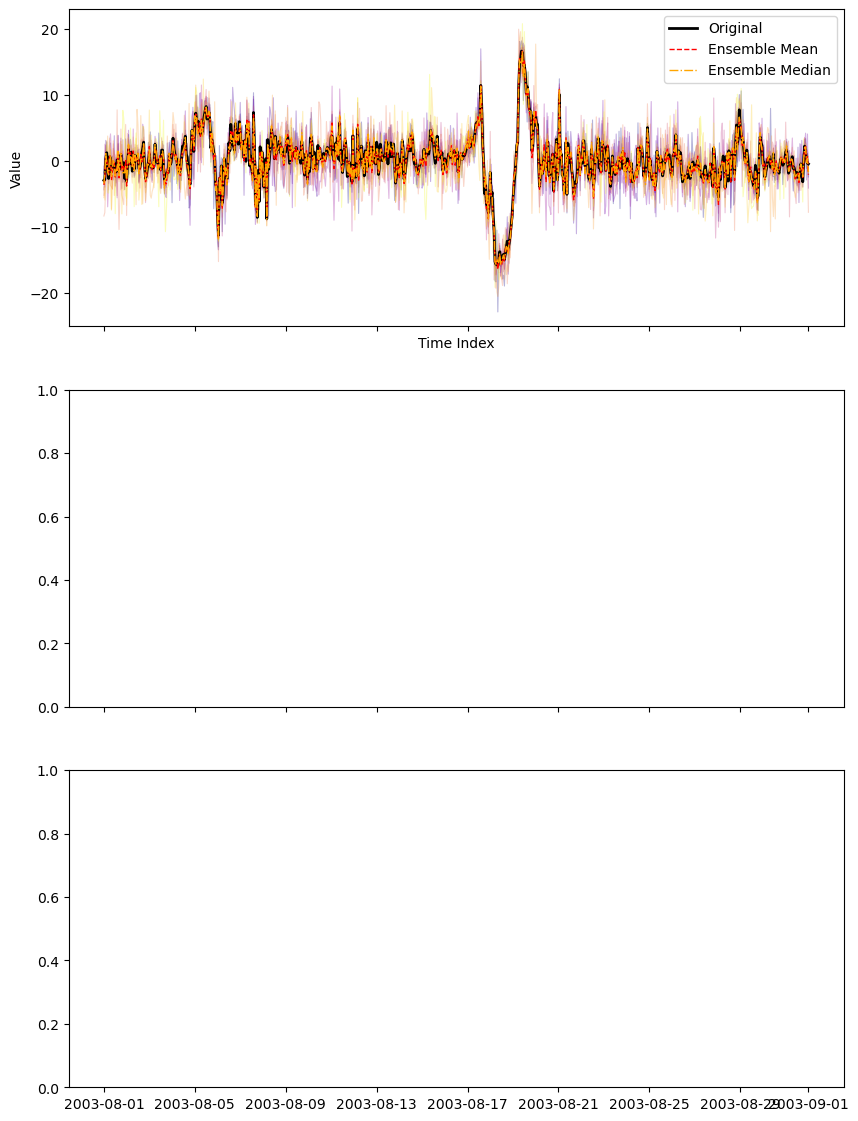

In [51]:
fig, ax = plt.subplots(3, 1, figsize=(10, 14), sharex=True)

_ = plot_ensemble(y_dat['DateTime'].to_numpy(), y_dat[cols[1]].to_numpy(), 
                  ens_dat[:,:,0], ax=ax[0], plot_mean=True, plot_median=True)



ax[0].plot(fit_dat['DateTime'].to_numpy(), fit_dat[cols[1]].to_numpy(), label='Bz')
ax[0].plot(fit_dat['DateTime'].to_numpy(), fitted_dat[:,0], label='ARIMA')
ax[0].legend()
ax[0].set_title('Comparison of Original and ARIMA for defining Residuals')

ax[1].plot(fit_dat['DateTime'].to_numpy(), fit_dat[cols[2]].to_numpy(), label='Vsw')
ax[1].plot(fit_dat['DateTime'].to_numpy(), fitted_dat[:,1], label='ARIMA')
ax[1].legend()

ax[2].plot(fit_dat['DateTime'].to_numpy(), fit_dat[cols[3]].to_numpy(), label='Pressure')
ax[2].plot(fit_dat['DateTime'].to_numpy(), fitted_dat[:,2], label='ARIMA')
ax[2].legend()

